In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

## Plot distribution of genera and functions across samples from CuratedMetagenomicData 

In [2]:
# Load data
X_genera = pd.read_csv(f'../data/genera/all/processed/X.tsv', index_col=0, sep="\t")
X_functions = pd.read_csv(f'../data/functions/all/processed/X.tsv', index_col=0, sep="\t")

In [3]:
X_genera.shape, X_functions.shape

((20455, 430), (20455, 623))

In [7]:
def plot_distr(X, data_type, col_dark, col_light):
    # For each feature, count proportion samples sharing it
    X = X.astype('bool').astype('int')
    samples_n = X.shape[0]
    feat_distr = X.sum(axis=0) / samples_n

    # Plot ditribution
    fig, ax = plt.subplots(figsize=(6, 5))

    # Add cumulative distribution on secondary axis
    ax2 = ax.twinx()
    sorted_distr = np.sort(feat_distr)
    cumulative = np.arange(1, len(sorted_distr) + 1) / len(sorted_distr)
    ax2.fill_between(sorted_distr, cumulative, color=col_light, alpha=0.3)
    ax2.set_ylabel(f'Proportion of {data_type}', fontsize=12, color=col_dark)
    ax2.tick_params(axis='y', labelcolor=col_dark)
    ax2.set_yticks(np.arange(0, 1, 0.1))

    # Plot histogram of feature proportions
    counts, bins, patches = ax.hist(feat_distr, bins=30, edgecolor='black', color=col_light)
    ax.set_xticks(np.arange(0, 1, 0.1))

    max_count = max(counts) if len(counts) > 0 else 1
    ax2.set_ylim(0, 1.0)  # Proportion goes from 0 to 1

    # Add inverse cumulative sum with dashed line
    inverse_cumulative = 1 - cumulative
    ax2.plot(sorted_distr, inverse_cumulative, color=col_dark, linewidth=2, linestyle='--')


    # Customize the plot
    ax.set_xlabel('Proportion of healthy samples', fontsize=12)
    ax.set_ylabel(f'Number of {data_type}', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'../images/distr_{data_type}.png', dpi=300, bbox_inches='tight')

    plt.show()

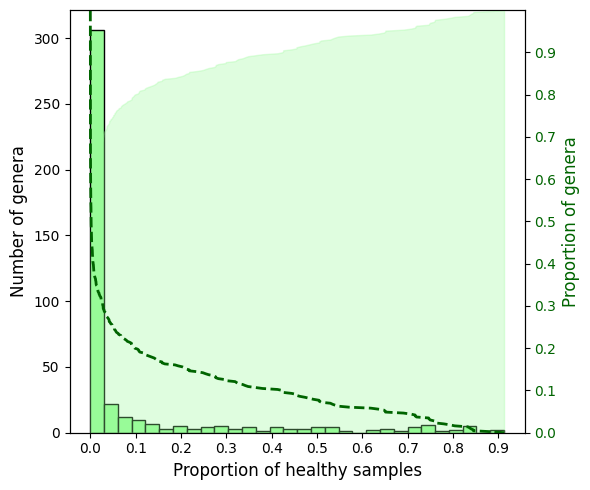

In [8]:
plot_distr(X_genera, 'genera', col_dark='darkgreen', col_light='palegreen')

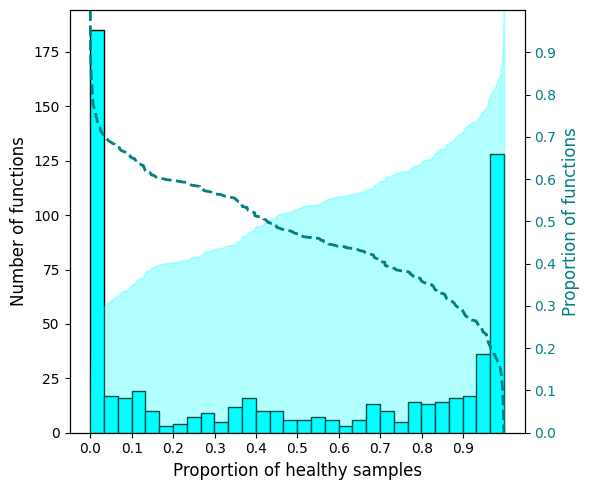

In [9]:
plot_distr(X_functions, 'functions', col_dark='teal', col_light='aqua')